In [1]:
import sys
import cmath
import math
import os
import h5py
import matplotlib.pyplot as plt   # plots
import numpy as np
import time
import warnings

from liblibra_core import *
import util.libutil as comn
from libra_py import units
import libra_py.models.Holstein as Holstein
import libra_py.models.Morse as Morse

from libra_py import dynamics_plotting
import libra_py.data_savers as data_savers

warnings.filterwarnings('ignore')

colors = {}
colors.update({"11": "#8b1a0e"})  # red       
colors.update({"12": "#FF4500"})  # orangered 
colors.update({"13": "#B22222"})  # firebrick 
colors.update({"14": "#DC143C"})  # crimson   
colors.update({"21": "#5e9c36"})  # green
colors.update({"22": "#006400"})  # darkgreen  
colors.update({"23": "#228B22"})  # forestgreen
colors.update({"24": "#808000"})  # olive      
colors.update({"31": "#8A2BE2"})  # blueviolet
colors.update({"32": "#00008B"})  # darkblue  
colors.update({"41": "#2F4F4F"})  # darkslategray

clrs_index = ["11", "21", "31", "41", "12", "22", "32", "13","23", "14", "24"]


def compute_model(q, params, full_id):
    model = params["model"]
    res = None
    if model==1:        
        res = Holstein.Holstein2(q, params, full_id) 
    elif model==2:        
        res = Holstein.Holstein2_rev(q, params, full_id) 
    elif model==3:
        res = Holstein.Holstein2_grad(q, params, full_id)    
    
    elif model==11:
        res = Morse.general(q, params, full_id)
    elif model==12:
        res = Morse.general_ad(q, params, full_id)
    elif model==13:
        res = Morse.general_grad(q, params, full_id)
    else:
        pass #res = compute_model_nbra_files(q, params, full_id)            
    return res

#### HOLSTEIN
model_params1 = {"model":1, "model0":1, "nstates":2, "E_n":[0.0,  0.0], "x_n":[0.0,  2.5],"k_n":[0.002, 0.005],"V":0.000}
model_params2 = {"model":2, "model0":1, "nstates":2, "E_n":[0.0,  0.0], "x_n":[0.0,  2.5],"k_n":[0.002, 0.005],"V":0.000}
model_params3 = {"model":3, "model0":1, "nstates":2, "E_n":[0.0,  0.0], "x_n":[0.0,  2.5],"k_n":[0.002, 0.005],"V":0.000}

model_params5 = {"model":1, "model0":1, "nstates":2, "E_n":[0.0,  0.0], "x_n":[0.0,  2.5],"k_n":[0.002, 0.005],"V":0.01}
model_params6 = {"model":2, "model0":1, "nstates":2, "E_n":[0.0,  0.0], "x_n":[0.0,  2.5],"k_n":[0.002, 0.005],"V":0.01}
model_params7 = {"model":3, "model0":1, "nstates":2, "E_n":[0.0,  0.0], "x_n":[0.0,  2.5],"k_n":[0.002, 0.005],"V":0.01}

model_params9 = {"model":1, "model0":1, "nstates":2, "E_n":[0.0,  0.0], "x_n":[0.0,  2.5],"k_n":[0.002, 0.005],"V":0.001}
model_params10 = {"model":2, "model0":1, "nstates":2, "E_n":[0.0,  0.0], "x_n":[0.0,  2.5],"k_n":[0.002, 0.005],"V":0.001}
model_params11 = {"model":3, "model0":1, "nstates":2, "E_n":[0.0,  0.0], "x_n":[0.0,  2.5],"k_n":[0.002, 0.005],"V":0.001}


#### MORSE
model_params21 = {"model":11, "model0":3, "nstates":3}; Morse.set_Coronado_Xing_Miller_params(model_params21, 3)
model_params22 = {"model":12, "model0":3, "nstates":3}; Morse.set_Coronado_Xing_Miller_params(model_params22, 3)


model_params24 = {"model":11, "model0":3, "nstates":3}; Morse.set_Coronado_Xing_Miller_params(model_params24, 2)
model_params25 = {"model":12, "model0":3, "nstates":3}; Morse.set_Coronado_Xing_Miller_params(model_params25, 2)


all_model_params = [model_params1, model_params2, model_params3,
                    model_params5, model_params6, model_params7,
                    model_params9, model_params10, model_params11,
                    model_params21, model_params22, 
                    model_params24, model_params25
                   ]
ad_params = {"figsize":[21, 7], "titlesize":15, "labelsize":20, "fontsize": 15, "xticksize":15, "yticksize":15,
               "colors": colors, "clrs_index": clrs_index,
               "prefix":F"case", "save_figures":0, "do_show":1,
               "plotting_option":1, "nac_idof":0 }
ana_params = {"figsize":[21, 7], "titlesize":15, "labelsize":20, "fontsize": 15, "xticksize":15, "yticksize":15,
               "colors": colors, "clrs_index": clrs_index,
               "prefix":F"case", "save_figures":0, "do_show":1,
               "plotting_option":1, "nac_idof":0 }

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

<Figure size 640x480 with 0 Axes>

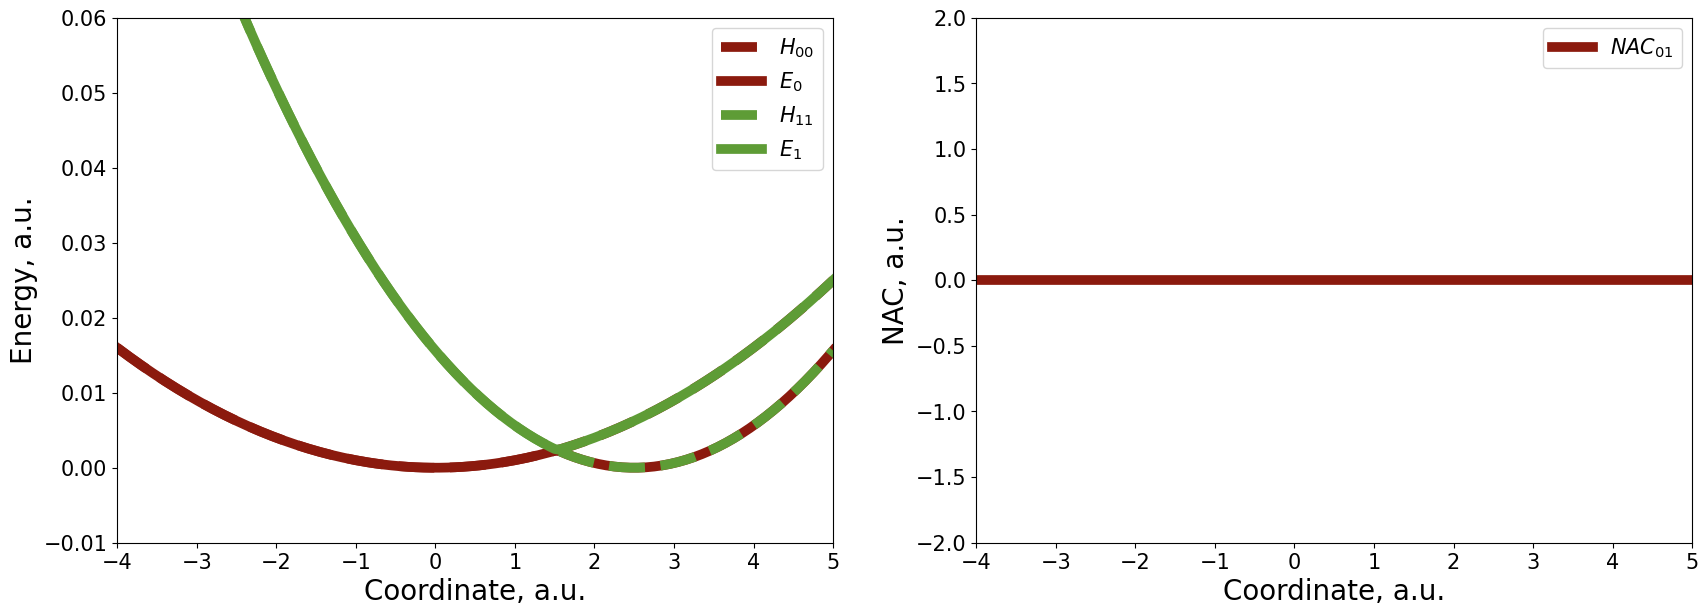

Elapsed: 0.3955 seconds


In [2]:
# Holstein 1: ANANALYTICAL
plot_params = ana_params
# Model 1
starting_time=time.time()
plot_params.update( { "xlim":[-4, 5], "ylim":[-0.01, 0.06], "ylim2":[-2, 2], "show_nac_abs":0 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params1 ], [0, 1], -4.0, 5.0, 0.05, plot_params)
ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


<Figure size 640x480 with 0 Axes>

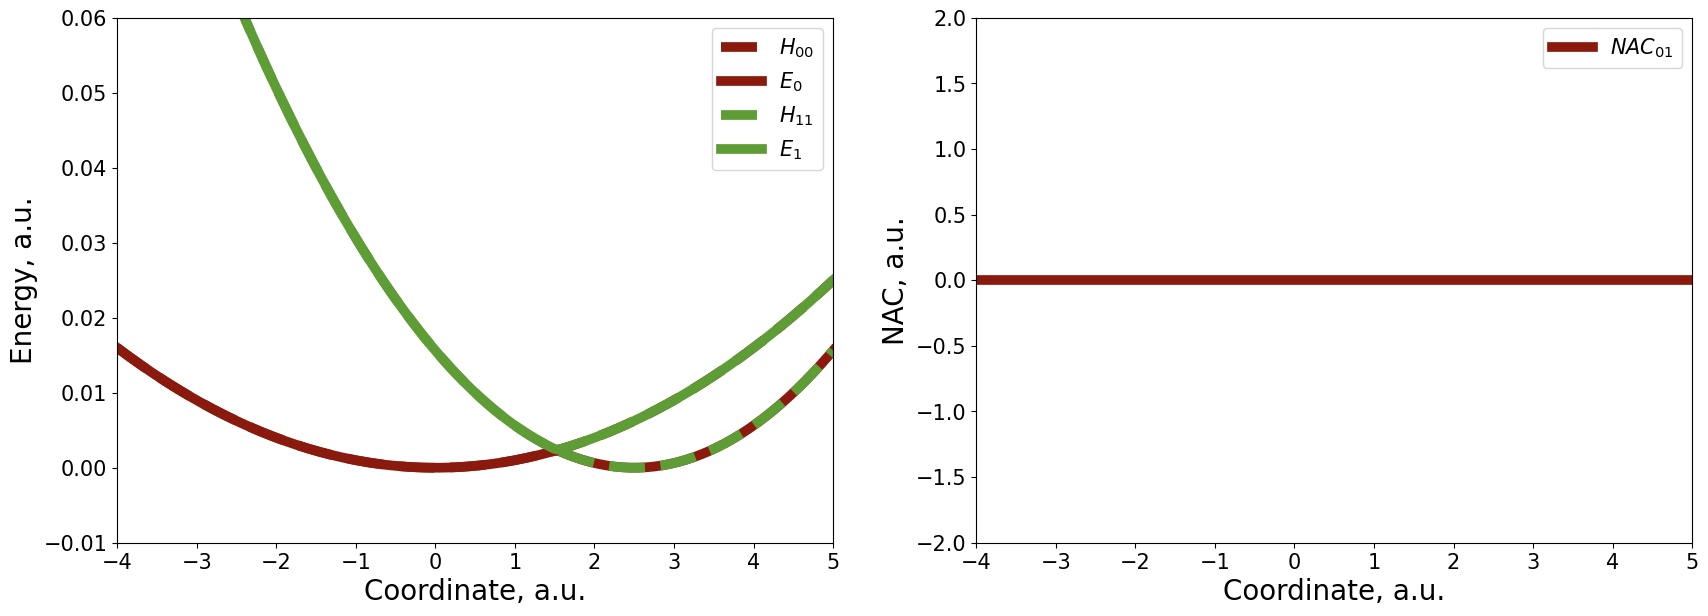

Elapsed: 3.8575 seconds


In [3]:
# Holstein 2: AUTODIFF
plot_params = ad_params

starting_time=time.time()
plot_params.update( { "xlim":[-4, 5], "ylim":[-0.01, 0.06], "ylim2":[-2, 2], "show_nac_abs":0 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params2 ], [0, 1], -4.0, 5.0, 0.05, plot_params)
ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")

<Figure size 640x480 with 0 Axes>

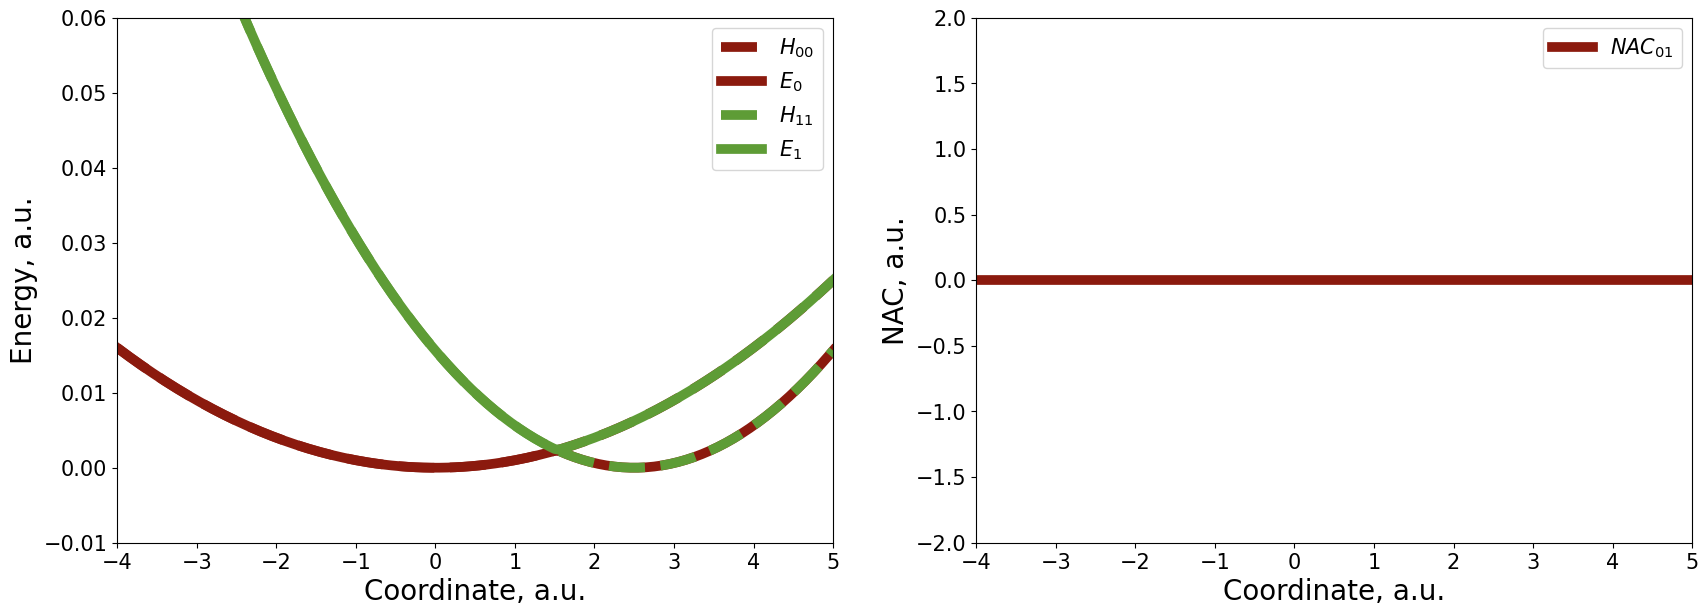

Elapsed: 1.0326 seconds


In [4]:
# Holstein 2: AUTODIFF
plot_params = ad_params

starting_time=time.time()
plot_params.update( { "xlim":[-4, 5], "ylim":[-0.01, 0.06], "ylim2":[-2, 2], "show_nac_abs":0 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params3 ], [0, 1], -4.0, 5.0, 0.05, plot_params)
ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")

<Figure size 640x480 with 0 Axes>

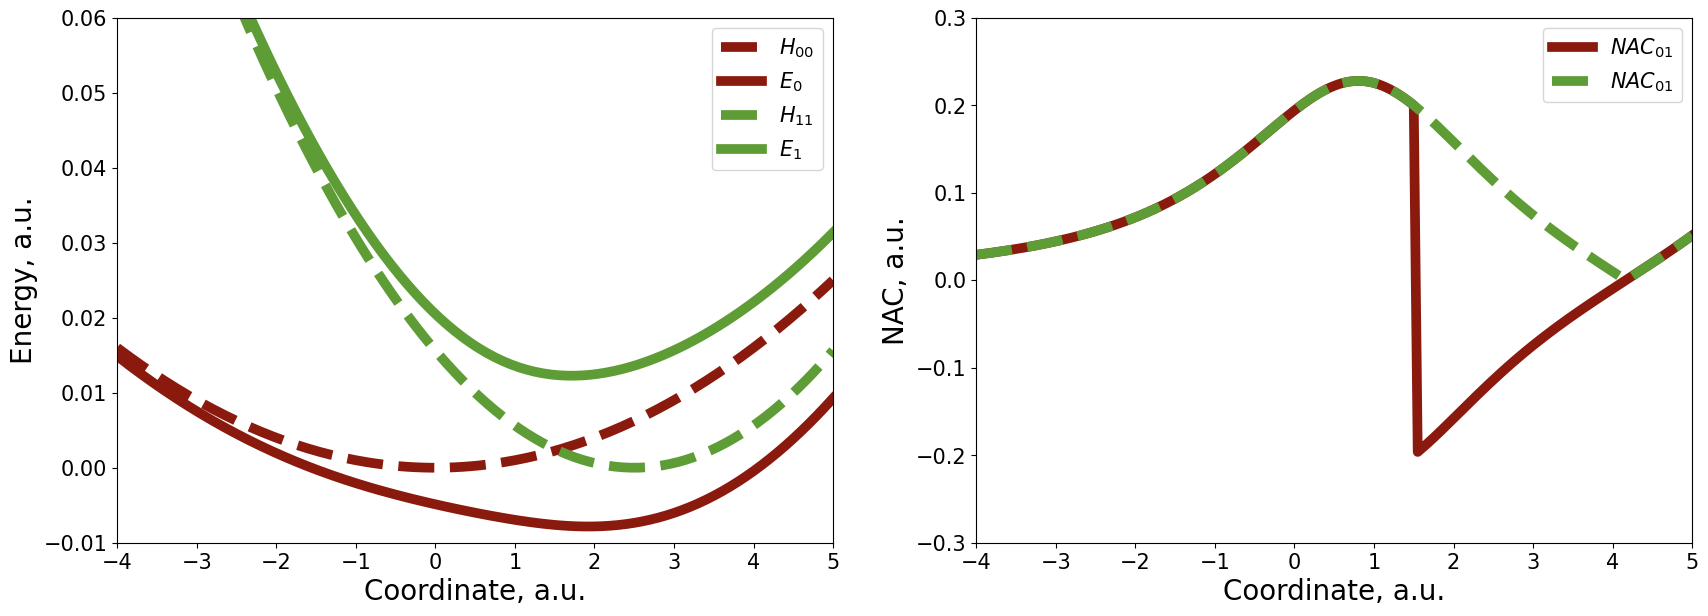

Elapsed: 0.2533 seconds


In [5]:
# HOSTEIN ANANALYTICAL
plot_params = ana_params


starting_time=time.time()

plot_params.update( { "xlim":[-4, 5], "ylim":[-0.01, 0.06], "ylim2":[-0.3, 0.3],"show_nac_abs":1 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params5 ], [0, 1], -4.0, 5.0, 0.05, plot_params)

ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")

<Figure size 640x480 with 0 Axes>

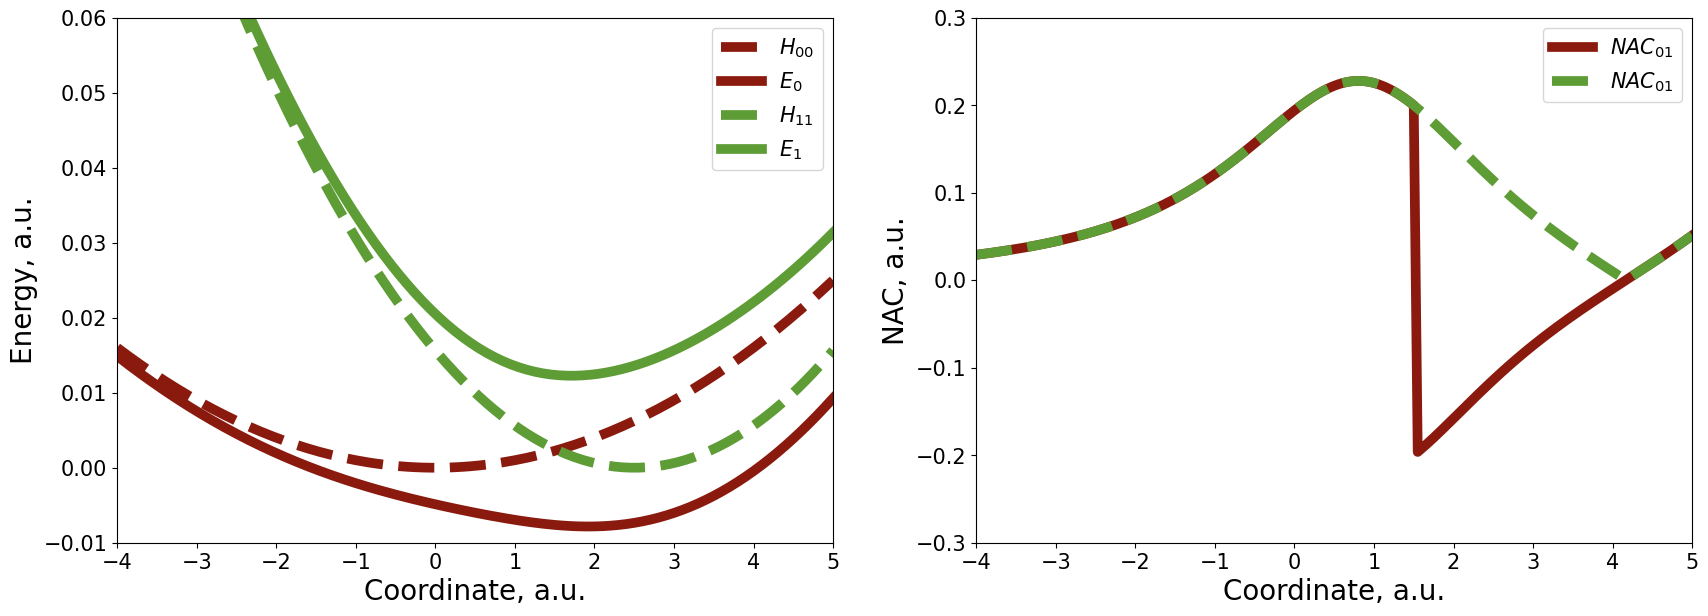

Elapsed: 2.6896 seconds


In [6]:
# HOSTEIN AUTODIFF
plot_params = ad_params


starting_time=time.time()

plot_params.update( { "xlim":[-4, 5], "ylim":[-0.01, 0.06], "ylim2":[-0.3, 0.3],"show_nac_abs":1 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params6 ], [0, 1], -4.0, 5.0, 0.05, plot_params)

ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")

<Figure size 640x480 with 0 Axes>

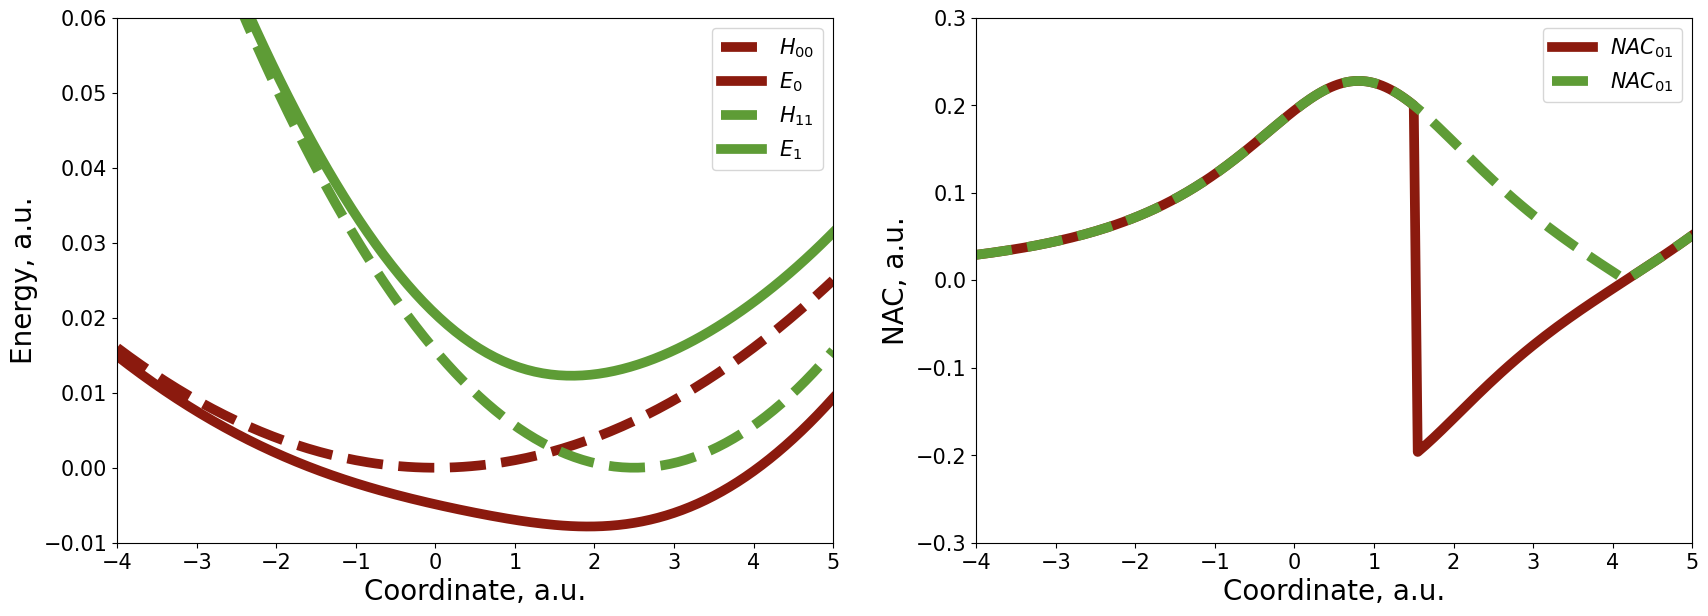

Elapsed: 0.9483 seconds


In [7]:
# HOSTEIN AUTODIFF
plot_params = ad_params


starting_time=time.time()

plot_params.update( { "xlim":[-4, 5], "ylim":[-0.01, 0.06], "ylim2":[-0.3, 0.3],"show_nac_abs":1 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params7 ], [0, 1], -4.0, 5.0, 0.05, plot_params)

ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")

<Figure size 640x480 with 0 Axes>

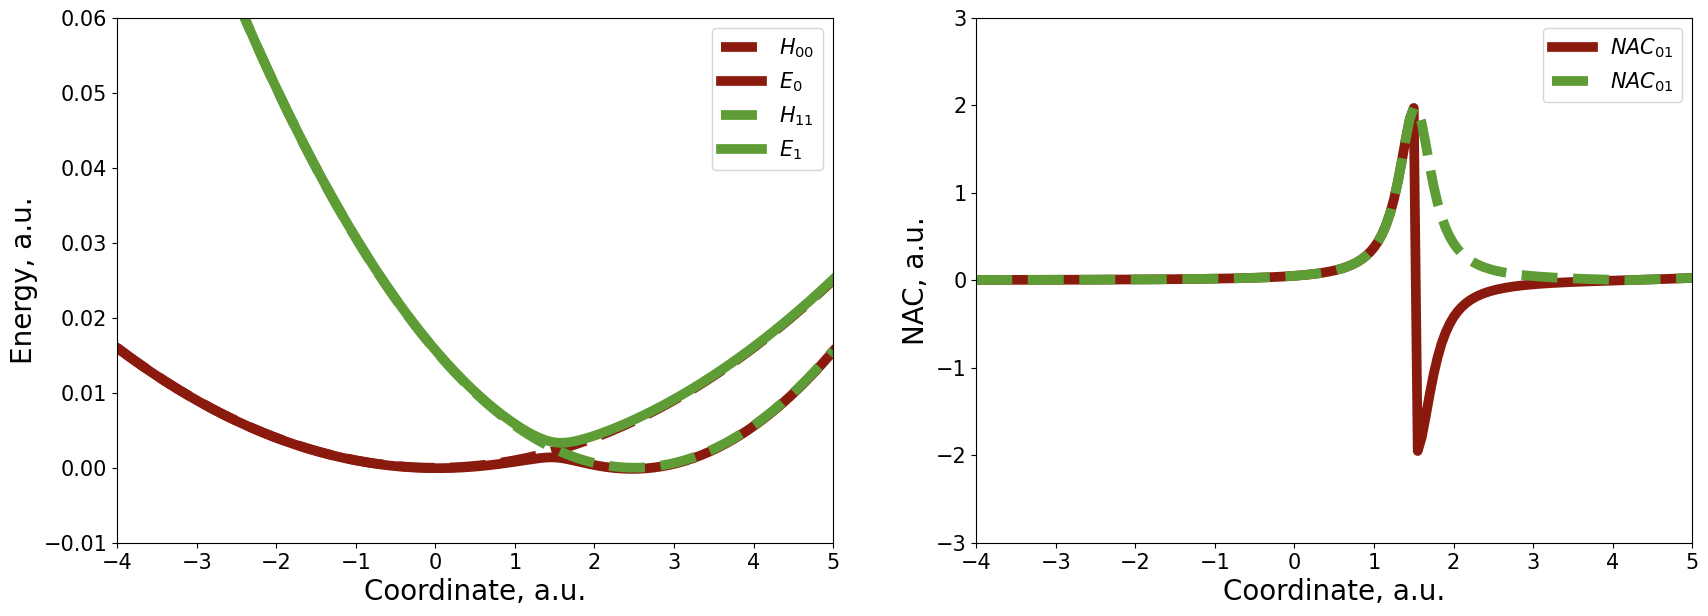

Elapsed: 0.1739 seconds


In [8]:
# HOSTEIN ANALYTICAL
plot_params = ad_params


starting_time=time.time()

plot_params.update( { "xlim":[-4, 5], "ylim":[-0.01, 0.06], "ylim2":[-3, 3], "show_nac_abs":1 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params9 ], [0, 1], -4.0, 5.0, 0.05, plot_params)

ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")

<Figure size 640x480 with 0 Axes>

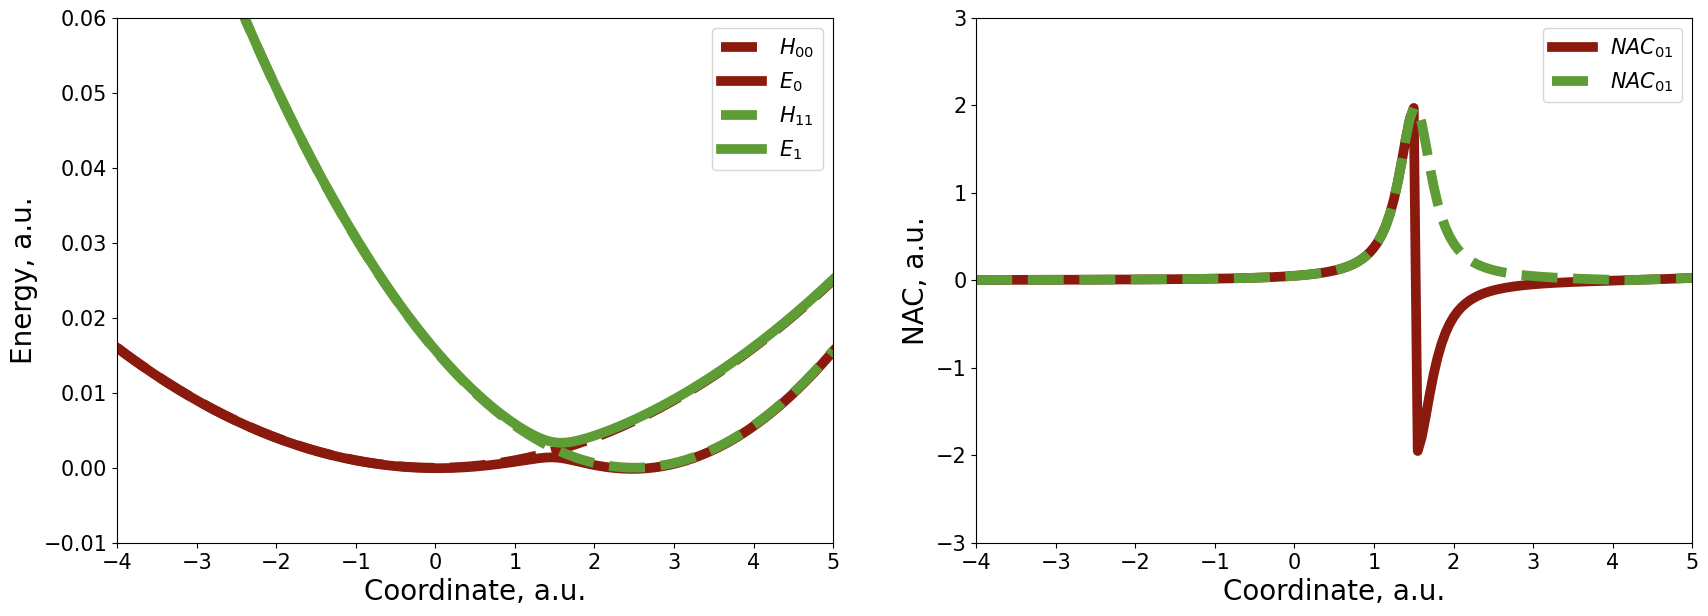

Elapsed: 2.7623 seconds


In [9]:
# HOSTEIN AUTODIFF
plot_params = ad_params


starting_time=time.time()

plot_params.update( { "xlim":[-4, 5], "ylim":[-0.01, 0.06], "ylim2":[-3, 3], "show_nac_abs":1 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params10 ], [0, 1], -4.0, 5.0, 0.05, plot_params)

ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")

<Figure size 640x480 with 0 Axes>

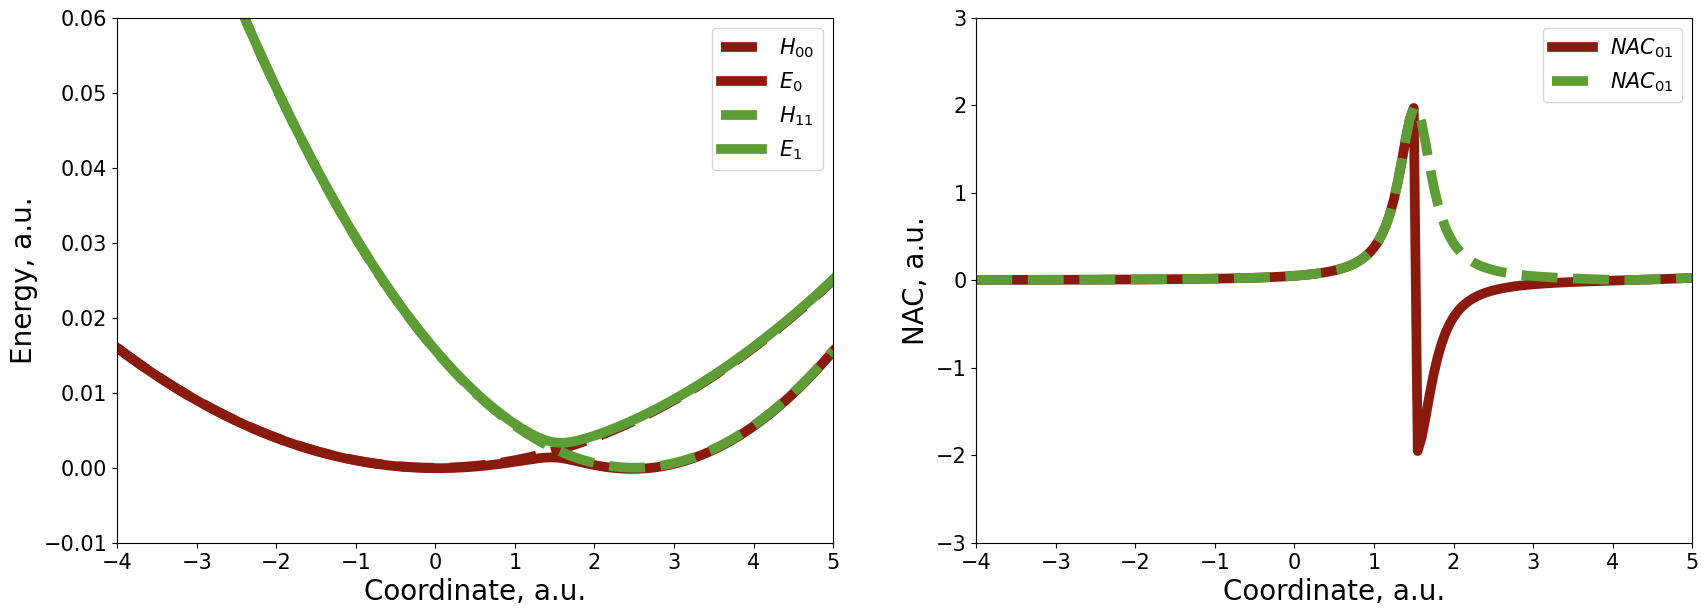

Elapsed: 1.0127 seconds


In [10]:
# HOSTEIN AUTODIFF
plot_params = ad_params


starting_time=time.time()

plot_params.update( { "xlim":[-4, 5], "ylim":[-0.01, 0.06], "ylim2":[-3, 3], "show_nac_abs":1 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params11 ], [0, 1], -4.0, 5.0, 0.05, plot_params)

ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")

<Figure size 640x480 with 0 Axes>

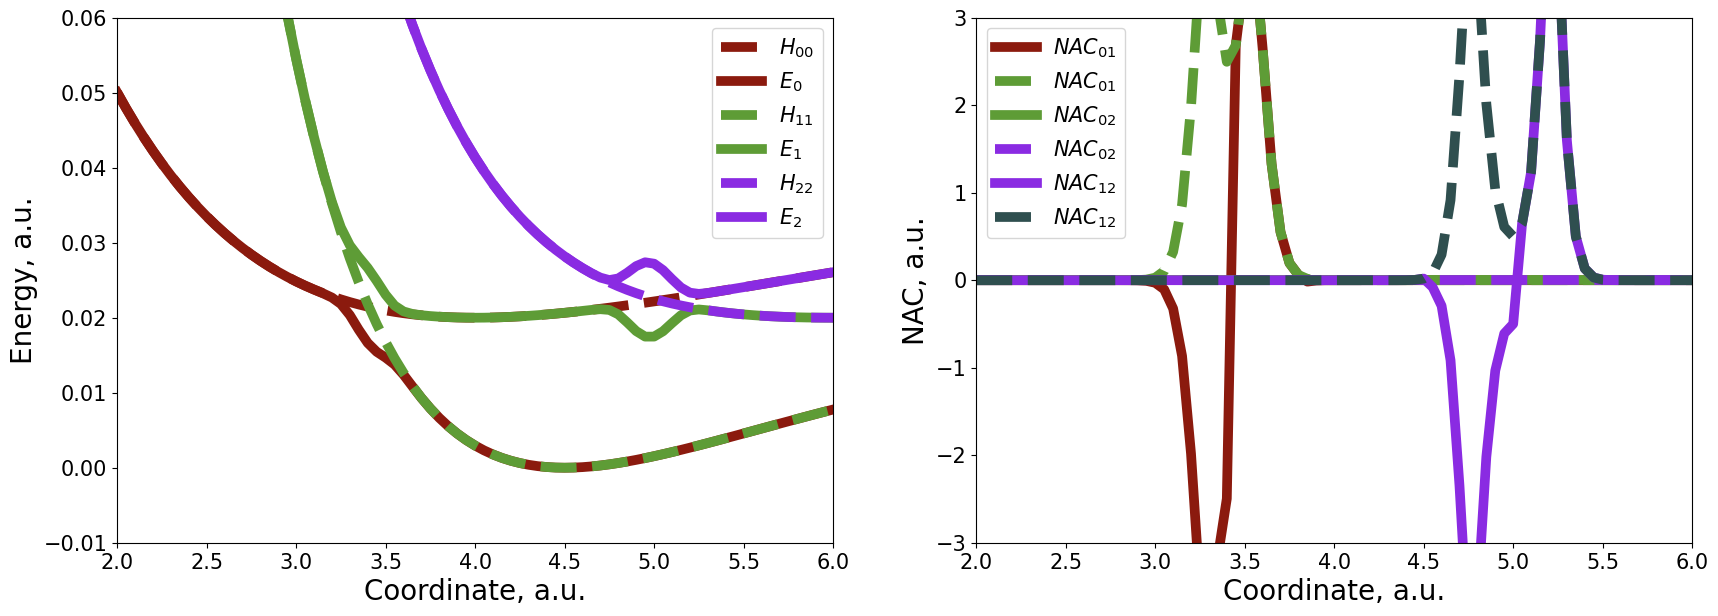

Elapsed: 0.2254 seconds


In [11]:
# MORSE ANALYTICAL
plot_params = ana_params

starting_time=time.time()


plot_params.update( { "xlim":[2, 6], "ylim":[-0.01, 0.06], "ylim2":[-3, 3], "show_nac_abs":1 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params21 ], [0, 1, 2], 2.0, 6.0, 0.05, plot_params)

ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")

<Figure size 640x480 with 0 Axes>

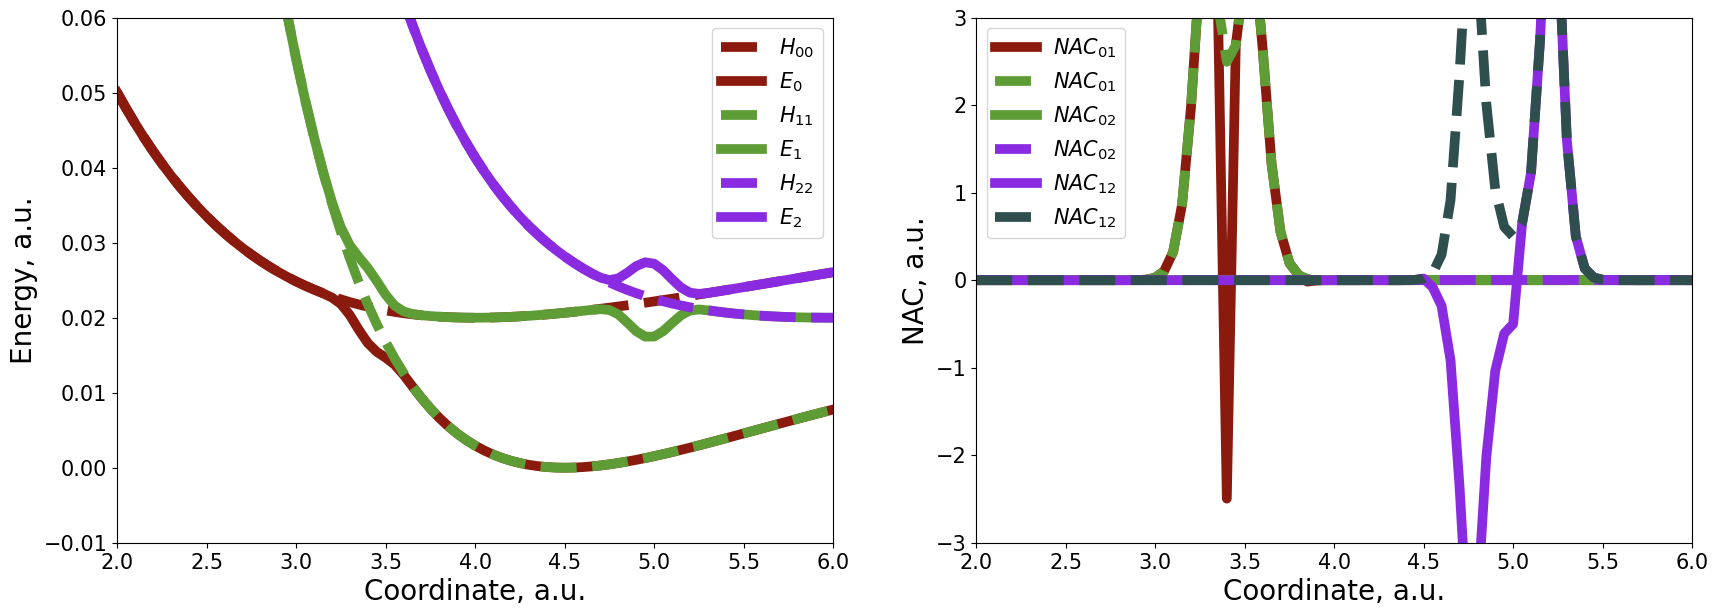

Elapsed: 2.5106 seconds


In [12]:
# MORSE AUTODIFF
plot_params = ad_params

starting_time=time.time()


plot_params.update( { "xlim":[2, 6], "ylim":[-0.01, 0.06], "ylim2":[-3, 3], "show_nac_abs":1 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params22 ], [0, 1, 2], 2.0, 6.0, 0.05, plot_params)

ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")

<Figure size 640x480 with 0 Axes>

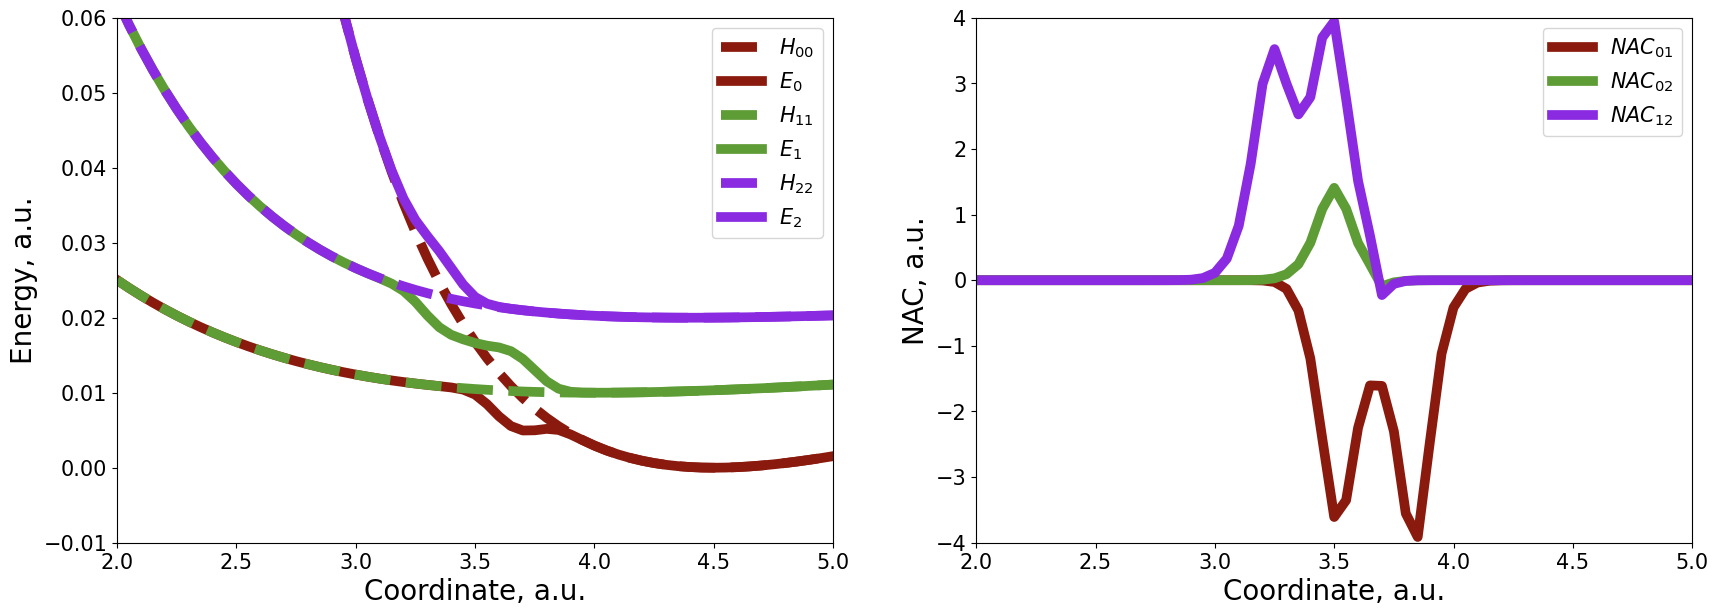

Elapsed: 0.2050 seconds


In [13]:
# MORSE ANALYTICAL
plot_params = ana_params

starting_time=time.time()
plot_params.update( { "xlim":[2, 5], "ylim":[-0.01, 0.06], "ylim2":[-4, 4], "show_nac_abs":0 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params24 ], [0, 1, 2], 2.0, 5.0, 0.05, plot_params)
ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")

<Figure size 640x480 with 0 Axes>

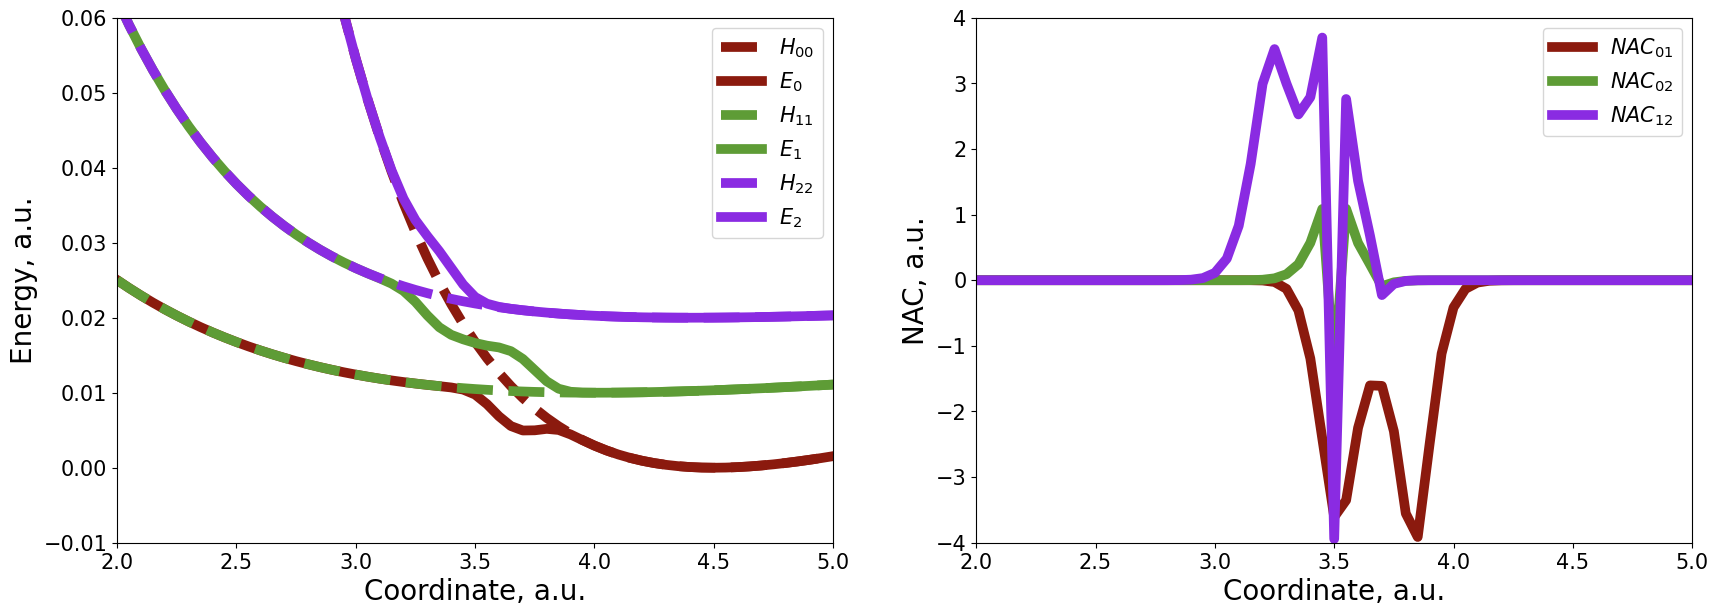

Elapsed: 1.1787 seconds


In [14]:
# MORSE AUTODIFF
plot_params = ad_params

starting_time=time.time()
plot_params.update( { "xlim":[2, 5], "ylim":[-0.01, 0.06], "ylim2":[-4, 4], "show_nac_abs":0 })
dynamics_plotting.plot_surfaces(compute_model, [ model_params25 ], [0, 1, 2], 2.0, 5.0, 0.05, plot_params)
ending_time=time.time()
elapsed=ending_time-starting_time
print(f"Elapsed: {elapsed:.4f} seconds")